In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name='tenx_10K_pbmc-v1_atacseq',
    save_path='scarf_datasets'
)

In [3]:
reader = scarf.CrH5Reader(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5'
)
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr',
    chunk_size=(1000, 2000)
)
writer.dump(batch_size=1000)

In [5]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr', 
    nthreads=4
)

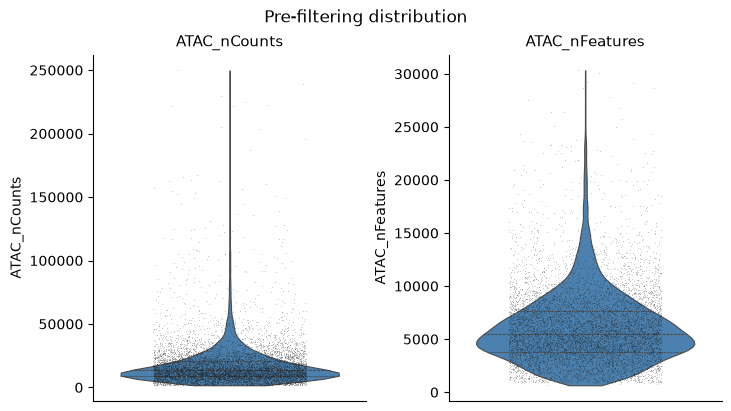

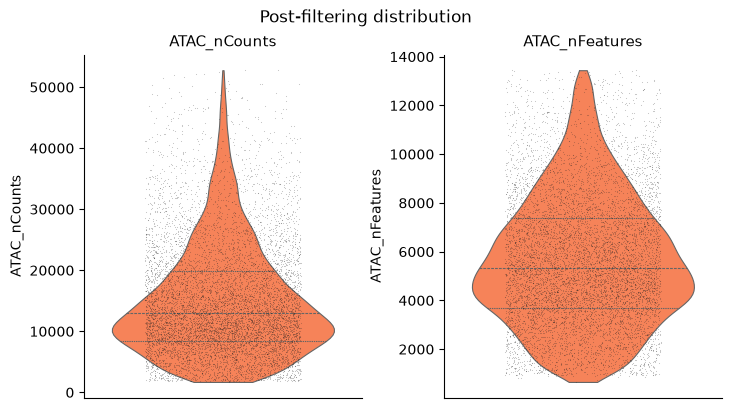

In [6]:
ds.auto_filter_cells()

In [7]:
ds.mark_prevalent_peaks(top_n=25000)

In [8]:
ds.ATAC.feats.head()

,I,ids,names,dropOuts,nCells,I__prevalent_peaks,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,8645,83,False,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,8529,199,False,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,6242,2486,True,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,8296,432,True,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,6850,1878,True,1.570790


In [9]:
ds.make_graph(
    feat_key='prevalent_peaks',
    k=21,
    dims=50,
    n_centroids=100,
    lsi_skip_first=True,
)

In [10]:
ds.run_umap(
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

In [11]:
ds.run_leiden_clustering(resolution=0.6)

In [12]:
ds.cells.head()

,I,ids,names,ATAC_UMAP2,ATAC_nFeatures,ATAC_nCounts,ATAC_UMAP1,ATAC_leiden_cluster
0,True,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,-3.563903,5546.0,13187.0,-8.421258,1
1,True,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,-6.865345,6586.0,16074.0,-9.543456,4
2,True,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,-0.445039,9214.0,28009.0,4.411285,7
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,NaN,30325.0,221747.0,NaN,-1
4,True,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,-3.051677,4922.0,11440.0,-7.912927,1


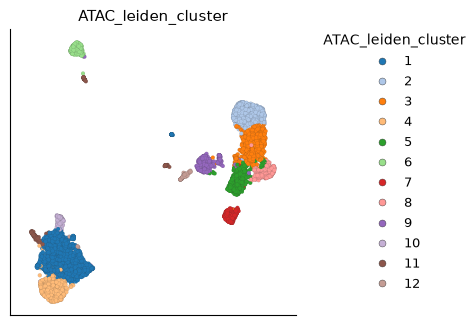

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [13]:
splt.embedding(
    ds,
    layout_key='ATAC_UMAP',
    color_by='ATAC_leiden_cluster',
)

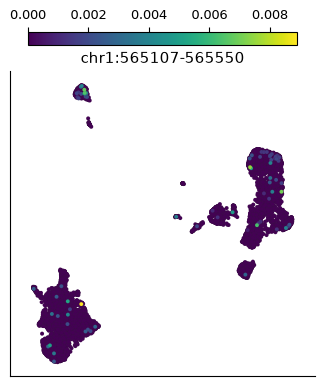

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [14]:
peak = str(ds.ATAC.feats.fetch_all('ids')[0])
splt.embedding(
    ds,
    layout_key='ATAC_UMAP',
    from_assay='ATAC',
    color_by=peak,
    sort_values=True,
)

In [15]:
scarf.fetch_dataset(
    dataset_name='annotations', 
    save_path='scarf_datasets'
)

In [16]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn='scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)

Chromosome chrM not in the input peak coordinates



Minimum cell count (6.539499236477921) is lower than size factor multiplier (1000)



In [17]:
ds

DataStore has 8426 (8728) cells with 2 assays: GeneScores ATAC
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_nFeatures', 'GeneScores_percentMito', 
            'GeneScores_percentRibo', 'GeneScores_nCounts', 'GeneScores_nFeatures', 'ATAC_UMAP2', 'ATAC_nCounts', 
            'ATAC_leiden_cluster', 'ATAC_UMAP1'
   ATAC assay has 86049 (89796) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__prevalent_peaks'
   GeneScores assay has 28357 (62446) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

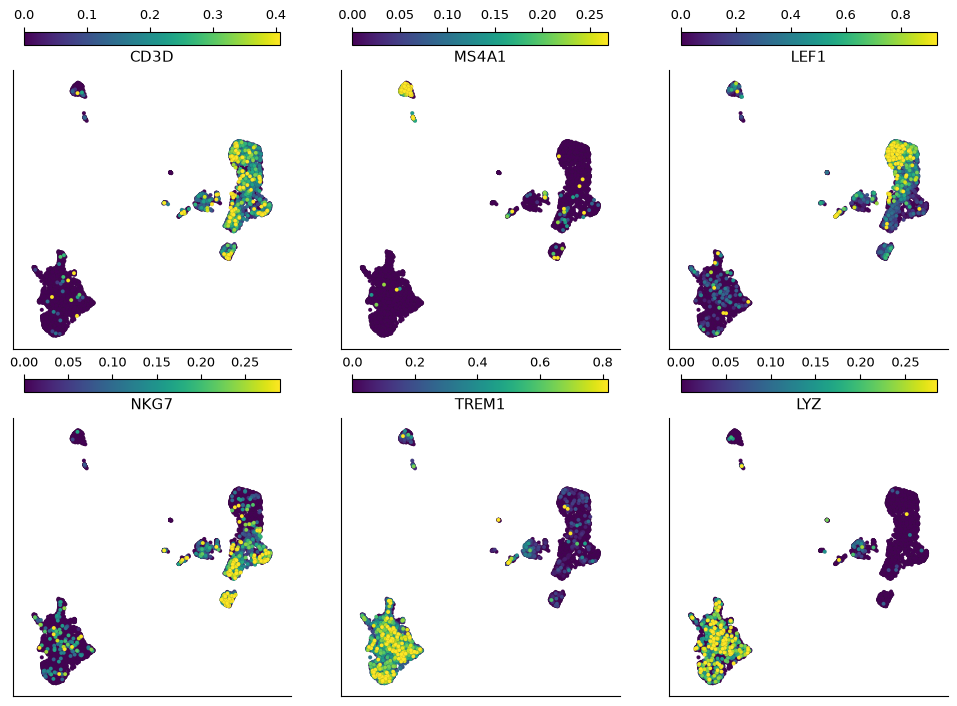

PlotResult(axes=6, tables=0, legends=6, scales=1, owns_figure=True, rendered=True)

In [18]:
splt.embedding(
    ds,
    layout_key='ATAC_UMAP',
    from_assay='GeneScores',
    color_by=['CD3D', 'MS4A1', 'LEF1', 'NKG7', 'TREM1', 'LYZ'],
    clip_fraction=0.01,
    n_columns=3,
    sort_values=True,
)